# NB14 — ESG 효율성 지수 분석
**최종 허브 5개·배정 권역 67개의 드론 배송 ESG/효율성 정량화**

NB13이 경로별 개선을 증명하면, NB14는 실제 배달 수요와 채택 시나리오를 활용하여 그 개선을 연간 ESG 효과로 확장합니다.

| 주요 입력 | 설명 |
|-----------|------|
| `nb13_route_comparison.csv` | 경로별 드론/오토바이 비교 (67개 경로) |
| `nb13_hub_summary.csv` | 허브별 NB13 요약 |
| `nb12_final_hubs.csv` | 최종 선정 5개 허브 정보 |
| `demand_dong_summary.csv` | 실제 월평균 배달 건수 (`avg_monthly_del_cnt`) |
| `delivery_zones.csv` | 배달 권역 유형 정보 |

**채택 시나리오:** 보수적 5% · 기준 10% · 적극 20%  
**ESG 가중치:** 탄소절감 35% · 시간절감 35% · 수요영향 15% · 운영신뢰성 15%  
**출력 7개:** `nb14_esg_route_impact.csv` · `nb14_esg_hub_summary.csv` · `nb14_esg_scenario_summary.csv`
· `nb14_esg_efficiency_index.csv` · `nb14_esg_diagnostics.json` · `nb14_esg_chart.png` · `nb14_esg_hub_map.html`

In [1]:
# ── §2 하드 게이트 ────────────────────────────────────────────────────────
import os, sys
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

BASE      = Path('C:/Users/jimin/Desktop/1_BITAmin_16기/1_Seongnam_reset')
PROCESSED = BASE / 'processed'

NB13_REQUIRED = [
    PROCESSED / 'nb13_route_comparison.csv',
    PROCESSED / 'nb13_hub_summary.csv',
    PROCESSED / 'nb12_final_hubs.csv',
    PROCESSED / 'nb12_hub_service_assignments.csv',
    PROCESSED / 'demand_dong_summary.csv',
]
missing = [str(f) for f in NB13_REQUIRED if not f.exists()]
if missing:
    raise FileNotFoundError(
        'Run NB13_delivery_impact_comparison.ipynb first.\n'
        + '\n'.join(f'  MISSING: {m}' for m in missing)
    )

_chk = pd.read_csv(PROCESSED / 'nb13_route_comparison.csv')
if len(_chk) == 0:
    raise ValueError(f'nb13_route_comparison.csv is empty. Re-run NB13.')
print(f'\u2705 Hard gate passed: {len(_chk)} routes confirmed in nb13_route_comparison.csv.')
del _chk

✅ Hard gate passed: 77 routes confirmed in nb13_route_comparison.csv.


In [2]:
# ── §3 환경 설정 ──────────────────────────────────────────────────────────
DATA  = PROCESSED
OUT14 = PROCESSED

# ── Drone adoption scenarios (% of annual orders fulfilled by drone)
ADOPTION_SCENARIOS = {
    'conservative': 0.05,
    'base':         0.10,
    'active':       0.20,
}

# ── ESG index component weights
ESG_W = {
    'carbon':      0.35,
    'time':        0.35,
    'demand':      0.15,
    'reliability': 0.15,
}
assert abs(sum(ESG_W.values()) - 1.0) < 1e-9, 'ESG weights must sum to 1'

# ── Demand scaling
ANNUAL_MONTHS = 12

# ── Carbon proxy (g CO2 / km) — WTW factors from NB13 (IPCC Tier 2 Asia 2-wheeler)
MOTO_CO2_G_KM  = 144.5
DRONE_CO2_G_KM = 21.0

print('§3 Config ready.')
print(f'  Adoption scenarios : {ADOPTION_SCENARIOS}')
print(f'  ESG weights        : {ESG_W}')

§3 Config ready.
  Adoption scenarios : {'conservative': 0.05, 'base': 0.1, 'active': 0.2}
  ESG weights        : {'carbon': 0.35, 'time': 0.35, 'demand': 0.15, 'reliability': 0.15}


In [3]:
# ── §4 데이터 로드 및 유효성 검사 ─────────────────────────────────────────
import json, re
import numpy as np

# 4-a  Core route-level data from NB13
df_r = pd.read_csv(DATA / 'nb13_route_comparison.csv')

# 4-b  Hub-level summary from NB13
df_hub13 = pd.read_csv(DATA / 'nb13_hub_summary.csv')

# 4-c  Final hub info from NB12
df_final_hubs = pd.read_csv(DATA / 'nb12_final_hubs.csv')

# 4-d  Real delivery demand by dong
df_demand = pd.read_csv(DATA / 'demand_dong_summary.csv')

# 4-e  Delivery zone types (optional enrichment)
dz_path = DATA / 'delivery_zones.csv'
df_zones = pd.read_csv(dz_path) if dz_path.exists() else pd.DataFrame()

# ── §5 필수 컬럼 검사 ─────────────────────────────────────────────────────
REQUIRED_COLS = [
    'assigned_lot_id', 'assigned_lot_name', 'target_h3_index',
    'CSV_ADMI_CD', 'Ds',
    'moto_time_est_min', 'drone_time_wx_adj_min',
    'drone_robot_full_wx_expected_eta_min',
    'time_saving_min', 'time_saving_pct', 'speedup_ratio', 'drone_faster',
    'time_saving_robot_full_min', 'drone_robot_full_faster',
    'co2_saving_g', 'co2_saving_robot_full_g',
    'straight_dist_m', 'road_dist_used_m',
    'route_mean_constraint_score', 'airspace_approval_required',
]
missing_cols = [c for c in REQUIRED_COLS if c not in df_r.columns]
assert not missing_cols, f'Missing required columns in nb13: {missing_cols}'

# Non-null guards
for col in ['moto_time_est_min', 'drone_time_wx_adj_min', 'co2_saving_g']:
    n_null = df_r[col].isna().sum()
    assert n_null == 0, f'{col} has {n_null} null(s) — check NB13 outputs.'

print(f'§4+§5 Loaded and validated.')
print(f'  Routes         : {len(df_r)}')
print(f'  Hubs           : {df_r["assigned_lot_id"].nunique()}')
print(f'  Demand dongs   : {len(df_demand)} rows')
print(f'  Delivery zones : {len(df_zones)} rows')

§4+§5 Loaded and validated.
  Routes         : 77
  Hubs           : 6
  Demand dongs   : 50 rows
  Delivery zones : 283 rows


In [4]:
# ── §6 실제 배달 수요 연결 ────────────────────────────────────────────────
# demand_dong_summary.avg_monthly_del_cnt → route-level monthly orders via Ds share
# Key: Ds is a relative index, NOT a delivery count.
# Allocation: route_monthly_orders = dong_monthly_cnt × (route_Ds / dong_total_Ds)

# Normalise CSV_ADMI_CD to int for reliable merge
df_r['_adm'] = pd.to_numeric(df_r['CSV_ADMI_CD'], errors='coerce').fillna(0).astype(int)
df_demand['_adm'] = df_demand['CSV_ADMI_CD'].astype(int)

# Total Ds per dong (sum across all routes that serve that dong)
dong_ds = df_r.groupby('_adm')['Ds'].sum().rename('_dong_Ds_total')
df_r = df_r.join(dong_ds, on='_adm')
df_r['_ds_share'] = df_r['Ds'] / df_r['_dong_Ds_total']

# Merge monthly delivery count from demand summary
df_r = df_r.merge(
    df_demand[['_adm', 'avg_monthly_del_cnt']],
    on='_adm', how='left'
)

# Route-level demand estimate
df_r['est_monthly_orders'] = df_r['avg_monthly_del_cnt'] * df_r['_ds_share']
df_r['est_annual_orders']  = df_r['est_monthly_orders'] * ANNUAL_MONTHS

# Demand join coverage check
n_matched = df_r['avg_monthly_del_cnt'].notna().sum()
n_unmatched = len(df_r) - n_matched
print(f'§6 Demand join: {n_matched}/{len(df_r)} routes matched to dong demand data.')
if n_unmatched > 0:
    unmatched_dongs = df_r.loc[df_r['avg_monthly_del_cnt'].isna(), 'target_ADM_NM'].unique()
    print(f'  \u26a0\ufe0f {n_unmatched} unmatched dongs: {list(unmatched_dongs)}')
    # Fill unmatched with dong-level median to avoid dropping routes
    median_cnt = df_demand['avg_monthly_del_cnt'].median()
    df_r['avg_monthly_del_cnt'].fillna(median_cnt, inplace=True)
    df_r['est_monthly_orders'].fillna(median_cnt * df_r['_ds_share'], inplace=True)
    df_r['est_annual_orders'].fillna(df_r['est_monthly_orders'] * ANNUAL_MONTHS, inplace=True)
    print(f'  Filled with median monthly count: {median_cnt:.0f}')

print(f'  Total estimated annual orders (all drones): {df_r["est_annual_orders"].sum():,.0f}')
print(df_r[['assigned_lot_name', 'target_ADM_NM', 'Ds', '_ds_share',
            'avg_monthly_del_cnt', 'est_monthly_orders', 'est_annual_orders']].head(5).to_string())

§6 Demand join: 77/77 routes matched to dong demand data.
  Total estimated annual orders (all drones): 180,607,843
  assigned_lot_name target_ADM_NM        Ds  _ds_share  avg_monthly_del_cnt  est_monthly_orders  est_annual_orders
0       분당도서관 부설주차장          구미1동  0.341859   0.500000        550131.333333       275065.666667          3300788.0
1       분당도서관 부설주차장           금곡동  0.335283   0.333333        610682.000000       203560.666667          2442728.0
2       분당도서관 부설주차장           금곡동  0.335283   0.333333        610682.000000       203560.666667          2442728.0
3       분당도서관 부설주차장          구미1동  0.341859   0.500000        550131.333333       275065.666667          3300788.0
4       분당도서관 부설주차장           금곡동  0.335283   0.333333        610682.000000       203560.666667          2442728.0


In [5]:
# ── §7 채택 시나리오별 연간 영향 추정 ─────────────────────────────────────
# Primary metric: direct drone (weather-adjusted) vs motorcycle
# Each scenario label is embedded in column names — no mixing.

for sc_name, rate in ADOPTION_SCENARIOS.items():
    px = f'sc_{sc_name}'   # column prefix

    # Annual drone-fulfilled orders under this scenario
    df_r[f'{px}_drone_orders'] = df_r['est_annual_orders'] * rate

    # ── Time impact (direct drone, primary)
    df_r[f'{px}_time_saved_min'] = (
        df_r[f'{px}_drone_orders'] * df_r['time_saving_min']
    )
    df_r[f'{px}_time_saved_hrs'] = df_r[f'{px}_time_saved_min'] / 60.0

    # ── CO2 impact (direct drone, primary)
    df_r[f'{px}_co2_saved_g']   = df_r[f'{px}_drone_orders'] * df_r['co2_saving_g']
    df_r[f'{px}_co2_saved_kg']  = df_r[f'{px}_co2_saved_g']  / 1_000.0
    df_r[f'{px}_co2_saved_ton'] = df_r[f'{px}_co2_saved_kg'] / 1_000.0

    # ── Distance impact
    df_r[f'{px}_moto_km_reduced']    = df_r[f'{px}_drone_orders'] * df_r['road_dist_used_m']  / 1_000.0
    df_r[f'{px}_drone_km_operated']  = df_r[f'{px}_drone_orders'] * df_r['straight_dist_m']   / 1_000.0

    # ── Sensitivity: robot-full scenario (time only — usually worse)
    df_r[f'{px}_time_saved_robot_min'] = (
        df_r[f'{px}_drone_orders'] * df_r['time_saving_robot_full_min']
    )
    df_r[f'{px}_co2_saved_robot_kg'] = (
        df_r[f'{px}_drone_orders'] * df_r['co2_saving_robot_full_g'] / 1_000.0
    )

print('§7 Annual impact columns created.')
for sc_name, rate in ADOPTION_SCENARIOS.items():
    px = f'sc_{sc_name}'
    tot_time = df_r[f'{px}_time_saved_hrs'].sum()
    tot_co2  = df_r[f'{px}_co2_saved_ton'].sum()
    tot_ord  = df_r[f'{px}_drone_orders'].sum()
    print(f'  [{sc_name:12s} {rate*100:4.0f}%]  '
          f'drone orders/yr={tot_ord:>9,.0f}  '
          f'time saved={tot_time:>8,.1f}h  '
          f'CO\u2082 saved={tot_co2:>6.2f}t')

§7 Annual impact columns created.
  [conservative    5%]  drone orders/yr=9,030,392  time saved=1,250,590.5h  CO₂ saved=2034.79t
  [base           10%]  drone orders/yr=18,060,784  time saved=2,501,181.0h  CO₂ saved=4069.57t
  [active         20%]  drone orders/yr=36,121,569  time saved=5,002,362.0h  CO₂ saved=8139.15t


In [6]:
# ── §8 ESG 효율성 지수 산출 ───────────────────────────────────────────────
# Route-level index; aggregated to hub later.
# Primary: direct-drone scenario metrics only.

def minmax_norm(s: pd.Series) -> pd.Series:
    """Min-max normalise to [0, 1]. Constant series → 0.5."""
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)

# ── Component scores
# Carbon: higher co2_saving_g per delivery → better
df_r['_score_carbon'] = minmax_norm(df_r['co2_saving_g'])

# Time: higher time_saving_min per delivery → better
df_r['_score_time'] = minmax_norm(df_r['time_saving_min'])

# Demand: higher Ds (demand index) → more impact potential → better
df_r['_score_demand'] = minmax_norm(df_r['Ds'])

# Reliability: lower constraint score + no approval burden → better
# route_mean_constraint_score: lower = fewer restrictions = better
# airspace_approval_required: True = operational overhead = penalty -0.2
_rel_raw = (
    (1.0 - minmax_norm(df_r['route_mean_constraint_score']))
    - 0.2 * df_r['airspace_approval_required'].astype(float)
)
df_r['_score_reliability'] = minmax_norm(_rel_raw.clip(0.0, 1.0))

# ── Composite ESG index
df_r['esg_index'] = (
    ESG_W['carbon']      * df_r['_score_carbon']      +
    ESG_W['time']        * df_r['_score_time']         +
    ESG_W['demand']      * df_r['_score_demand']       +
    ESG_W['reliability'] * df_r['_score_reliability']
)

# ESG tier labels
df_r['esg_tier'] = pd.cut(
    df_r['esg_index'],
    bins=[0, 0.35, 0.55, 0.75, 1.01],
    labels=['하(Low)', '중(Mid)', '상(High)', '최상(Excellent)'],
    right=False
)

print('§8 ESG Efficiency Index computed.')
print(df_r[['assigned_lot_name', 'target_ADM_NM', 'esg_index', 'esg_tier',
            '_score_carbon', '_score_time', '_score_demand', '_score_reliability']]
      .sort_values('esg_index', ascending=False)
      .head(10).to_string(index=False))
print(f'\n  ESG Index stats: mean={df_r["esg_index"].mean():.3f}, '
      f'min={df_r["esg_index"].min():.3f}, max={df_r["esg_index"].max():.3f}')
print('\n  Tier distribution:')
print(df_r['esg_tier'].value_counts().sort_index().to_string())

§8 ESG Efficiency Index computed.
assigned_lot_name target_ADM_NM  esg_index      esg_tier  _score_carbon  _score_time  _score_demand  _score_reliability
          태평4동 제1           복정동   0.791525 최상(Excellent)       0.953831     1.000000       0.171388            0.546504
          태평4동 제1           단대동   0.731938       상(High)       0.772043     0.854058       0.225053            0.860296
          태평4동 제1           성남동   0.708998       상(High)       0.654691     0.796139       0.549767            0.791615
               점골          서현2동   0.663161       상(High)       1.000000     0.467435       0.416287            0.580774
          태평4동 제1          태평4동   0.644497       상(High)       0.502283     0.690060       0.783661            0.730852
          태평4동 제1          태평1동   0.570568       상(High)       0.560900     0.701304       0.286782            0.571860
          태평4동 제1           중앙동   0.557041       상(High)       0.456171     0.620976       0.251381            0.948882
      

In [7]:
# ── §9 허브별 집계 ────────────────────────────────────────────────────────

def hub_agg(df, sc_names):
    agg_dict = {
        'n_routes'              : ('target_h3_index',          'count'),
        'total_Ds'              : ('Ds',                       'sum'),
        'avg_esg_index'         : ('esg_index',                'mean'),
        'max_esg_index'         : ('esg_index',                'max'),
        'min_esg_index'         : ('esg_index',                'min'),
        'avg_time_saving_min'   : ('time_saving_min',          'mean'),
        'avg_co2_saving_g'      : ('co2_saving_g',             'mean'),
        'total_est_annual_orders': ('est_annual_orders',       'sum'),
        'pct_airspace_approval' : ('airspace_approval_required', 'mean'),
        'avg_constraint_score'  : ('route_mean_constraint_score', 'mean'),
    }
    for sc in sc_names:
        px = f'sc_{sc}'
        agg_dict[f'{px}_drone_orders']    = (f'{px}_drone_orders',   'sum')
        agg_dict[f'{px}_time_saved_hrs']  = (f'{px}_time_saved_hrs', 'sum')
        agg_dict[f'{px}_co2_saved_ton']   = (f'{px}_co2_saved_ton',  'sum')
        agg_dict[f'{px}_moto_km_reduced'] = (f'{px}_moto_km_reduced','sum')
    return (
        df.groupby(['assigned_lot_id', 'assigned_lot_name'], dropna=False)
        .agg(**agg_dict)
        .reset_index()
        .sort_values('avg_esg_index', ascending=False)
    )

df_hub_esg = hub_agg(df_r, list(ADOPTION_SCENARIOS.keys()))
df_hub_esg['pct_airspace_approval'] *= 100

print('§9 Hub-level ESG aggregation:')
print(df_hub_esg[['assigned_lot_name', 'n_routes', 'avg_esg_index',
                   'avg_time_saving_min', 'avg_co2_saving_g',
                   'sc_base_time_saved_hrs', 'sc_base_co2_saved_ton']].to_string(index=False))

§9 Hub-level ESG aggregation:
assigned_lot_name  n_routes  avg_esg_index  avg_time_saving_min  avg_co2_saving_g  sc_base_time_saved_hrs  sc_base_co2_saved_ton
          태평4동 제1        14       0.527941            13.375401        225.521945           984161.953670            1003.257651
               점골        10       0.416468             7.768192        255.010480           292203.360703             592.110940
              맛고을        13       0.395020             7.908142        225.603049           411247.060322             810.046751
      분당도서관 부설주차장        13       0.325590             6.412814        210.619332           350434.424489             672.574364
       분당구청 부설주차장        13       0.316000             5.673938        182.819814           362444.751680             743.464971
         운중동공영주차장        14       0.291015             5.315099        194.946951           100689.462187             248.118526


In [8]:
# ── §10 시나리오별 도시 전체 집계 ─────────────────────────────────────────

scenario_rows = []
for sc_name, rate in ADOPTION_SCENARIOS.items():
    px = f'sc_{sc_name}'
    row = {
        'scenario'             : sc_name,
        'adoption_rate_pct'    : rate * 100,
        'drone_annual_orders'  : round(df_r[f'{px}_drone_orders'].sum(), 0),
        'time_saved_hrs'       : round(df_r[f'{px}_time_saved_hrs'].sum(), 1),
        'time_saved_days'      : round(df_r[f'{px}_time_saved_hrs'].sum() / 24, 1),
        'co2_saved_kg'         : round(df_r[f'{px}_co2_saved_kg'].sum(), 2),
        'co2_saved_ton'        : round(df_r[f'{px}_co2_saved_ton'].sum(), 3),
        'moto_km_reduced'      : round(df_r[f'{px}_moto_km_reduced'].sum(), 1),
        'drone_km_operated'    : round(df_r[f'{px}_drone_km_operated'].sum(), 1),
        # Robot-full sensitivity (usually negative time saving)
        'robot_time_saved_hrs' : round(df_r[f'{px}_time_saved_robot_min'].sum() / 60, 1),
        'robot_co2_saved_kg'   : round(df_r[f'{px}_co2_saved_robot_kg'].sum(), 2),
    }
    scenario_rows.append(row)
df_scenario = pd.DataFrame(scenario_rows)

print('§10 Scenario summary (city-wide annual estimates):')
print(df_scenario[['scenario','adoption_rate_pct','drone_annual_orders',
                   'time_saved_hrs','co2_saved_ton','moto_km_reduced']].to_string(index=False))

§10 Scenario summary (city-wide annual estimates):
    scenario  adoption_rate_pct  drone_annual_orders  time_saved_hrs  co2_saved_ton  moto_km_reduced
conservative                5.0            9030392.0       1250590.5       2034.787       15432352.3
        base               10.0           18060784.0       2501181.0       4069.573       30864704.7
      active               20.0           36121569.0       5002362.0       8139.146       61729409.4


In [9]:
# ── §11 행정구역별 집계 (기준 시나리오 기준) ─────────────────────────────

district_esg = (
    df_r.groupby(['target_GU_NM', 'target_ADM_NM'], dropna=False)
    .agg(
        n_routes              = ('target_h3_index',        'count'),
        avg_esg_index         = ('esg_index',              'mean'),
        total_Ds              = ('Ds',                     'sum'),
        avg_time_saving_min   = ('time_saving_min',        'mean'),
        avg_co2_saving_g      = ('co2_saving_g',           'mean'),
        total_est_annual_orders = ('est_annual_orders',    'sum'),
        base_time_saved_hrs   = ('sc_base_time_saved_hrs', 'sum'),
        base_co2_saved_ton    = ('sc_base_co2_saved_ton',  'sum'),
        pct_airspace_approval = ('airspace_approval_required', 'mean'),
    )
    .reset_index()
    .sort_values('avg_esg_index', ascending=False)
)
district_esg['pct_airspace_approval'] *= 100

print('§11 District ESG summary (base scenario, top 10 by ESG index):')
print(district_esg.head(10)
      [['target_GU_NM','target_ADM_NM','n_routes','avg_esg_index',
        'base_time_saved_hrs','base_co2_saved_ton']].to_string(index=False))

§11 District ESG summary (base scenario, top 10 by ESG index):
target_GU_NM target_ADM_NM  n_routes  avg_esg_index  base_time_saved_hrs  base_co2_saved_ton
         수정구           단대동         1       0.731938         58129.776762           64.675920
         중원구           성남동         1       0.708998        373790.250585          379.127867
         수정구          태평4동         1       0.644497        129668.007176          116.768717
         수정구          태평1동         1       0.570568         94704.982999           93.293099
         수정구           복정동         2       0.568416        104453.973194          166.502524
         중원구           중앙동         2       0.541679         40762.215277           35.464132
         수정구          수진1동         1       0.509299         46288.803901           41.608369
         분당구          수내3동         1       0.506296         41232.629557           91.610656
         분당구          서현2동         2       0.475432         67636.061918          115.084481
       

In [10]:
# ── §12 로봇 통합 배송 민감도 분석 ───────────────────────────────────────
# The robot-full leg (hub → robot → customer) is usually SLOWER than motorcycle.
# This section quantifies why it is not the primary scenario.

n_direct_faster = int(df_r['drone_faster'].sum())
n_robot_faster  = int(df_r['drone_robot_full_faster'].sum())

print('§12 Robot-full sensitivity analysis:')
print(f'  Direct drone faster than motorcycle : {n_direct_faster}/{len(df_r)} routes '
      f'({n_direct_faster/len(df_r)*100:.1f}%)')
print(f'  Robot-full faster than motorcycle   : {n_robot_faster}/{len(df_r)} routes '
      f'({n_robot_faster/len(df_r)*100:.1f}%)')
print(f'\n  Median direct-drone time saving : {df_r["time_saving_min"].median():.2f} min')
print(f'  Median robot-full time saving   : {df_r["time_saving_robot_full_min"].median():.2f} min')

# Base scenario comparison
base_direct_hrs  = df_r['sc_base_time_saved_hrs'].sum()
base_robot_hrs   = (df_r['sc_base_time_saved_robot_min'] / 60).sum()
base_direct_co2  = df_r['sc_base_co2_saved_kg'].sum()
base_robot_co2   = df_r['sc_base_co2_saved_robot_kg'].sum()

print(f'\n  Base scenario (10% adoption) comparison:')
print(f'    Direct drone time saved : {base_direct_hrs:>8,.1f} hrs/yr')
print(f'    Robot-full time delta   : {base_robot_hrs:>8,.1f} hrs/yr  ← negative = worse than moto')
print(f'    Direct drone CO\u2082 saved : {base_direct_co2:>8,.1f} kg/yr')
print(f'    Robot-full CO\u2082 saved   : {base_robot_co2:>8,.1f} kg/yr')
print(f'\n  \u2192 Direct drone is the primary scenario. '
      f'Robot-full remains a sensitivity only.')

§12 Robot-full sensitivity analysis:
  Direct drone faster than motorcycle : 77/77 routes (100.0%)
  Robot-full faster than motorcycle   : 2/77 routes (2.6%)

  Median direct-drone time saving : 8.21 min
  Median robot-full time saving   : -13.07 min

  Base scenario (10% adoption) comparison:
    Direct drone time saved : 2,501,181.0 hrs/yr
    Robot-full time delta   : -4,697,644.2 hrs/yr  ← negative = worse than moto
    Direct drone CO₂ saved : 4,069,573.2 kg/yr
    Robot-full CO₂ saved   : 3,855,820.1 kg/yr

  → Direct drone is the primary scenario. Robot-full remains a sensitivity only.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


...

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


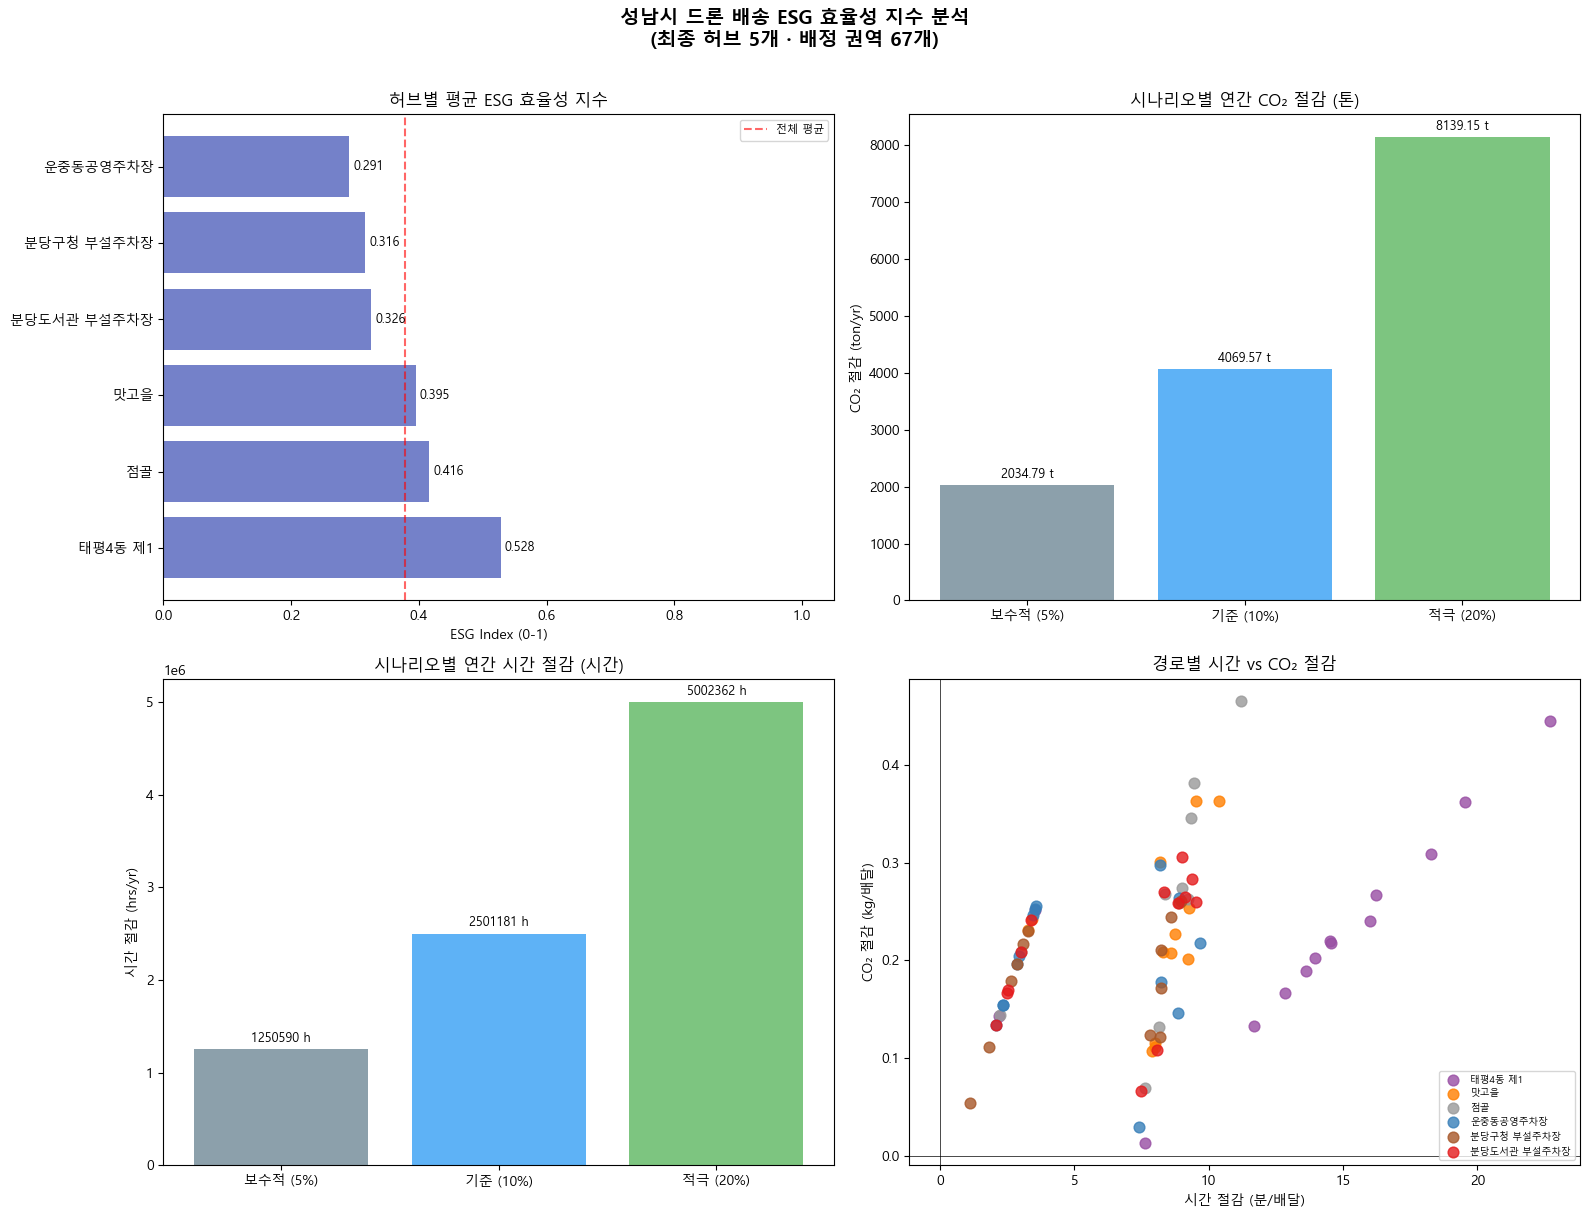

  Chart saved → C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_chart.png
  Map saved → C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_hub_map.html


In [11]:
# ── §13 시각화 ───────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
from folium.plugins import MarkerCluster

matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

SC_LABELS = {'conservative':'보수적 (5%)', 'base':'기준 (10%)', 'active':'적극 (20%)'}
SC_COLORS = {'conservative':'#78909C', 'base':'#42A5F5', 'active':'#66BB6A'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    '성남시 드론 배송 ESG 효율성 지수 분석\n(최종 허브 5개 · 배정 권역 67개)',
    fontsize=14, fontweight='bold', y=1.01
)

# ── 13-a: ESG index by hub (horizontal bar)
ax = axes[0, 0]
hub_names = df_hub_esg['assigned_lot_name'].astype(str)
bars = ax.barh(hub_names, df_hub_esg['avg_esg_index'], color='#5C6BC0', alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_title('허브별 평균 ESG 효율성 지수')
ax.set_xlabel('ESG Index (0-1)')
ax.axvline(df_r['esg_index'].mean(), color='red', linestyle='--', alpha=0.6, label='전체 평균')
ax.legend(fontsize=8)

# ── 13-b: Annual CO2 saving by scenario
ax = axes[0, 1]
sc_list = list(ADOPTION_SCENARIOS.keys())
x = range(len(sc_list))
co2_vals = [df_scenario.loc[df_scenario['scenario'] == sc, 'co2_saved_ton'].values[0]
            for sc in sc_list]
bars2 = ax.bar(x, co2_vals, color=[SC_COLORS[s] for s in sc_list], alpha=0.85)
ax.bar_label(bars2, fmt='%.2f t', padding=3, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels([SC_LABELS[s] for s in sc_list])
ax.set_title('시나리오별 연간 CO₂ 절감 (톤)')
ax.set_ylabel('CO₂ 절감 (ton/yr)')

# ── 13-c: Annual time saving by scenario
ax = axes[1, 0]
time_vals = [df_scenario.loc[df_scenario['scenario'] == sc, 'time_saved_hrs'].values[0]
             for sc in sc_list]
bars3 = ax.bar(x, time_vals, color=[SC_COLORS[s] for s in sc_list], alpha=0.85)
ax.bar_label(bars3, fmt='%.0f h', padding=3, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels([SC_LABELS[s] for s in sc_list])
ax.set_title('시나리오별 연간 시간 절감 (시간)')
ax.set_ylabel('시간 절감 (hrs/yr)')

# ── 13-d: Route scatter — time saving vs CO2, coloured by hub
ax = axes[1, 1]
hub_ids = df_r['assigned_lot_id'].unique()
palette = plt.cm.Set1(np.linspace(0, 0.9, len(hub_ids)))
color_map = dict(zip(hub_ids, palette))
for hub_id, grp in df_r.groupby('assigned_lot_id'):
    ax.scatter(
        grp['time_saving_min'], grp['co2_saving_g'] / 1000,
        c=[color_map[hub_id]], alpha=0.8, s=60,
        label=grp['assigned_lot_name'].iloc[0]
    )
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('경로별 시간 vs CO₂ 절감')
ax.set_xlabel('시간 절감 (분/배달)')
ax.set_ylabel('CO₂ 절감 (kg/배달)')
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
chart_path = OUT14 / 'nb14_esg_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Chart saved → {chart_path}')

# ── Folium interactive map
m = folium.Map(location=[37.43, 127.14], zoom_start=12, tiles='CartoDB positron')

def esg_color(score):
    if score >= 0.75: return 'darkgreen'
    if score >= 0.55: return 'green'
    if score >= 0.35: return 'orange'
    return 'red'

zone_layer = MarkerCluster(name='배송 권역 (ESG색)', show=True).add_to(m)
for _, row in df_r.dropna(subset=['target_lat', 'target_lon']).iterrows():
    popup_html = (
        f"<b>{row.get('target_ADM_NM', '')}</b><br>"
        f"ESG Index: {row['esg_index']:.3f}<br>"
        f"Tier: {str(row['esg_tier'])}<br>"
        f"Time saving: {row['time_saving_min']:.1f} min<br>"
        f"CO2 saving: {row['co2_saving_g']/1000:.2f} kg"
    )
    folium.CircleMarker(
        [row['target_lat'], row['target_lon']], radius=7,
        color=esg_color(row['esg_index']), fill=True, fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=240),
    ).add_to(zone_layer)

# Hub markers (coordinates from route data)
hub_pts = (df_r.dropna(subset=['hub_lat', 'hub_lon'])
           .groupby('assigned_lot_id').first()[['hub_lat', 'hub_lon', 'assigned_lot_name']]
           .reset_index())
for _, h in hub_pts.iterrows():
    folium.Marker(
        [h['hub_lat'], h['hub_lon']],
        popup=folium.Popup(f"<b>Hub: {h['assigned_lot_name']}</b>", max_width=200),
        icon=folium.Icon(color='blue', icon='home'),
    ).add_to(m)

folium.LayerControl().add_to(m)

legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
    'background:white;padding:10px;border:2px solid grey;font-size:12px">'
    '<b>ESG 등급</b><br>'
    '<span style="color:darkgreen">&#9679;</span> 최상 (&ge; 0.75)<br>'
    '<span style="color:green">&#9679;</span> 상 (0.55&ndash;0.75)<br>'
    '<span style="color:orange">&#9679;</span> 중 (0.35&ndash;0.55)<br>'
    '<span style="color:red">&#9679;</span> 하 (&lt; 0.35)'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend_html))

map_path = OUT14 / 'nb14_esg_hub_map.html'
m.save(str(map_path))
print(f'  Map saved → {map_path}')

In [12]:
# ── §14 결과 저장 ─────────────────────────────────────────────────────────

# 14-a: Route-level ESG impact
_route_cols = [
    'assigned_lot_id','assigned_lot_name','target_h3_index',
    'target_ADM_NM','target_GU_NM','Ds','delivery_zone',
    'moto_time_est_min','drone_time_wx_adj_min','drone_robot_full_wx_expected_eta_min',
    'time_saving_min','time_saving_pct','speedup_ratio','drone_faster',
    'time_saving_robot_full_min','drone_robot_full_faster',
    'co2_saving_g','co2_saving_robot_full_g',
    'straight_dist_m','road_dist_used_m',
    'airspace_approval_required','route_mean_constraint_score',
    'avg_monthly_del_cnt','est_monthly_orders','est_annual_orders',
]
# Add all scenario columns
_sc_cols = [c for c in df_r.columns if c.startswith('sc_')]
_route_cols = [c for c in _route_cols if c in df_r.columns] + _sc_cols

route_path = OUT14 / 'nb14_esg_route_impact.csv'
df_r[_route_cols].to_csv(route_path, index=False, encoding='utf-8-sig')
print(f'  Saved: {route_path}  ({len(df_r)} rows)')

# 14-b: Hub ESG summary
hub_path = OUT14 / 'nb14_esg_hub_summary.csv'
df_hub_esg.to_csv(hub_path, index=False, encoding='utf-8-sig')
print(f'  Saved: {hub_path}  ({len(df_hub_esg)} rows)')

# 14-c: Scenario summary
sc_path = OUT14 / 'nb14_esg_scenario_summary.csv'
df_scenario.to_csv(sc_path, index=False, encoding='utf-8-sig')
print(f'  Saved: {sc_path}  ({len(df_scenario)} rows)')

# 14-d: ESG index per route (lean version)
idx_path = OUT14 / 'nb14_esg_efficiency_index.csv'
df_r[['assigned_lot_id','assigned_lot_name','target_h3_index',
      'target_ADM_NM','target_GU_NM','Ds','esg_index','esg_tier',
      '_score_carbon','_score_time','_score_demand','_score_reliability']].to_csv(
    idx_path, index=False, encoding='utf-8-sig'
)
print(f'  Saved: {idx_path}  ({len(df_r)} rows)')

# 14-e: Diagnostics JSON
base = df_scenario.loc[df_scenario['scenario'] == 'base'].iloc[0]
diag = {
    'notebook'                     : 'NB14_esg_efficiency_index',
    'run_date'                     : pd.Timestamp.now().isoformat(),
    'n_routes'                     : len(df_r),
    'n_hubs'                       : int(df_r['assigned_lot_id'].nunique()),
    'demand_join_coverage'         : f'{n_matched}/{len(df_r)}',
    'esg_index_mean'               : round(float(df_r['esg_index'].mean()), 4),
    'esg_index_min'                : round(float(df_r['esg_index'].min()), 4),
    'esg_index_max'                : round(float(df_r['esg_index'].max()), 4),
    'pct_direct_drone_faster'      : round(float(df_r['drone_faster'].mean() * 100), 2),
    'pct_robot_full_faster'        : round(float(df_r['drone_robot_full_faster'].mean() * 100), 2),
    'base_scenario': {
        'adoption_rate_pct'        : 10.0,
        'drone_annual_orders'      : int(base['drone_annual_orders']),
        'time_saved_hrs'           : float(base['time_saved_hrs']),
        'co2_saved_ton'            : float(base['co2_saved_ton']),
        'moto_km_reduced'          : float(base['moto_km_reduced']),
    },
    'primary_scenario'             : 'direct_drone_weather_adjusted',
    'sensitivity_scenario'         : 'robot_full_leg',
    'narrative'                    : (
        'NB13 proved route-level improvement. NB14 scales that improvement '
        'into ESG impact using real card-delivery demand volume '
        'and transparent adoption scenarios.'
    ),
    'outputs': {
        'route_impact'     : str(route_path),
        'hub_summary'      : str(hub_path),
        'scenario_summary' : str(sc_path),
        'efficiency_index' : str(idx_path),
        'chart'            : str(chart_path),
        'map'              : str(map_path),
    }
}
diag_path = OUT14 / 'nb14_esg_diagnostics.json'
with open(diag_path, 'w', encoding='utf-8') as _f:
    json.dump(diag, _f, ensure_ascii=False, indent=2)
print(f'  Saved: {diag_path}')

# ── Final validation assertions
assert len(df_r) > 0, 'Route table is empty'
assert df_r['moto_time_est_min'].notna().all(),        'moto_time_est_min has nulls'
assert df_r['drone_time_wx_adj_min'].notna().all(),    'drone_time_wx_adj_min has nulls'
assert df_r['co2_saving_g'].notna().all(),             'co2_saving_g has nulls'
assert df_r['esg_index'].between(0, 1).all(),          'ESG index out of [0,1]'
assert route_path.exists(),                            'route_impact not written'
assert hub_path.exists(),                              'hub_summary not written'
assert diag_path.exists(),                             'diagnostics not written'

print('\n' + '=' * 65)
print('  NB14 ESG 효율성 지수 — 최종 요약')
print('=' * 65)
print(f'  분석 경로 수                 : {len(df_r)}개')
print(f'  평균 ESG 지수                : {diag["esg_index_mean"]:.4f}')
print(f'  드론 직접 배송 우위 비율     : {diag["pct_direct_drone_faster"]:.1f}%')
print(f'  로봇 통합 배송 우위 비율     : {diag["pct_robot_full_faster"]:.1f}%  ← 민감도 전용')
print(f'  기준 시나리오 (10% 채택)')
print(f'    연간 드론 배달             : {diag["base_scenario"]["drone_annual_orders"]:,}건')
print(f'    연간 시간 절감             : {diag["base_scenario"]["time_saved_hrs"]:,.1f}시간')
print(f'    연간 CO\u2082 절감         : {diag["base_scenario"]["co2_saved_ton"]:.3f}톤')
print(f'    연간 오토바이 km 절감      : {diag["base_scenario"]["moto_km_reduced"]:,.1f}km')
print('=' * 65)
print('\n\u2705 All assertions passed. NB14 complete.')

  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_route_impact.csv  (77 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_hub_summary.csv  (6 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_scenario_summary.csv  (3 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_efficiency_index.csv  (77 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb14_esg_diagnostics.json

  NB14 ESG 효율성 지수 — 최종 요약
  분석 경로 수                 : 77개
  평균 ESG 지수                : 0.3780
  드론 직접 배송 우위 비율     : 100.0%
  로봇 통합 배송 우위 비율     : 2.6%  ← 민감도 전용
  기준 시나리오 (10% 채택)
    연간 드론 배달             : 18,060,784건
    연간 시간 절감             : 2,501,181.0시간
    연간 CO₂ 절감         : 4069.573톤
    연간 오토바이 km 절감      : 30,864,704.7km

✅ All assertions passed. NB14 complete.
